In [1]:
import kaggle
from pathlib import Path

DATA_DIR = Path("../data/raw")
DATA_DIR.mkdir(parents=True, exist_ok=True)

kaggle.api.authenticate()
kaggle.api.dataset_download_files(
    "teejmahal20/airline-passenger-satisfaction",
    path=DATA_DIR,
    unzip=True,
)

print("Pobrane pliki:")
for f in sorted(DATA_DIR.iterdir()):
    print(f"  {f.name}")

Dataset URL: https://www.kaggle.com/datasets/teejmahal20/airline-passenger-satisfaction
Pobrane pliki:
  test.csv
  train.csv


In [2]:
import sys
sys.path.append("..")

from src.preprocessing import (
    load_data,
    analyze_missing_values,
    clean_data,
    build_preprocessor,
    plot_correlation_matrix,
    plot_target_correlation,
    engineer_features,
    split_X_y,
)
from src.evaluation import evaluate, cross_validate_model
from src.models.xgboost_model import tune_hyperparameters

In [3]:
train, test = load_data()

print("=== Train ===")
print(train.shape)
train.head()

=== Train ===
(103904, 24)


,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [4]:
print("=== Braki w train ===")
analyze_missing_values(train)

print("\n=== Braki w test ===")
analyze_missing_values(test)

=== Braki w train ===
                          count  percent
Arrival Delay in Minutes    310      0.3

=== Braki w test ===
                          count  percent
Arrival Delay in Minutes     83     0.32


In [5]:
train_clean = clean_data(train)
test_clean = clean_data(test)

print("Train po czyszczeniu:", train_clean.shape)
print("Test po czyszczeniu: ", test_clean.shape)

Train po czyszczeniu: (103904, 23)
Test po czyszczeniu:  (25976, 23)


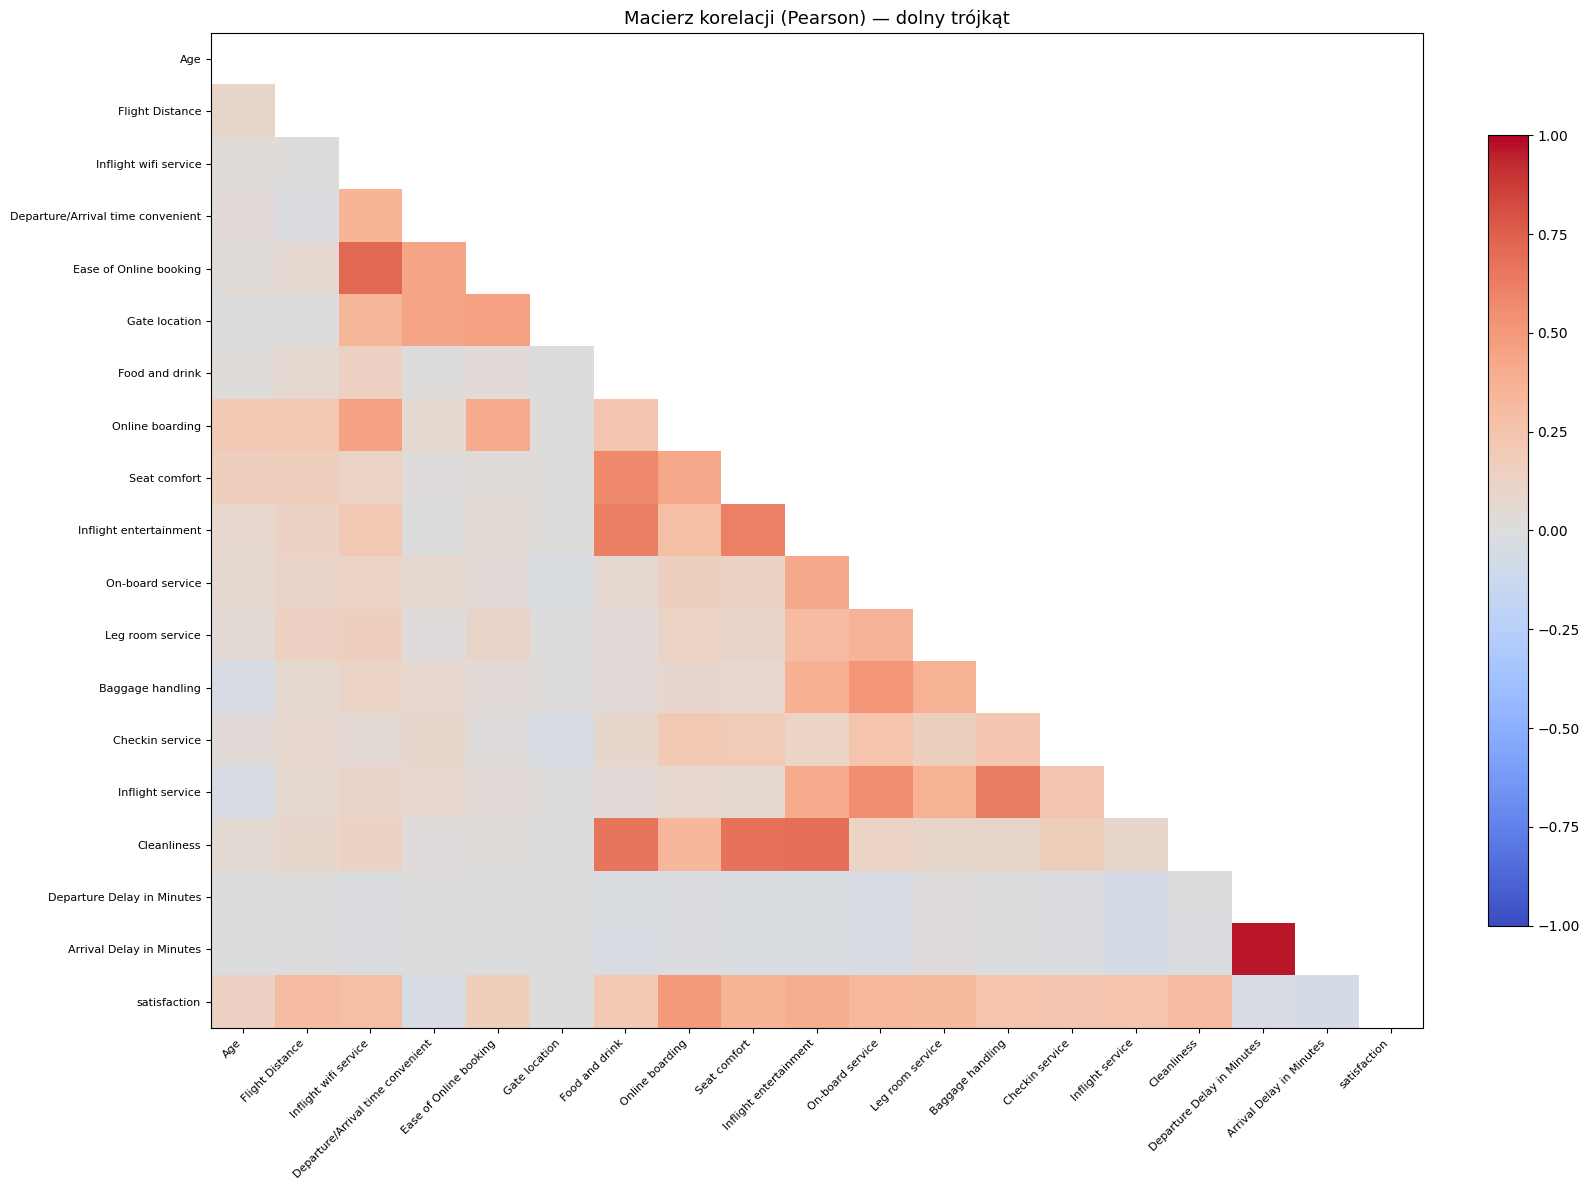

In [6]:
plot_correlation_matrix(train_clean)

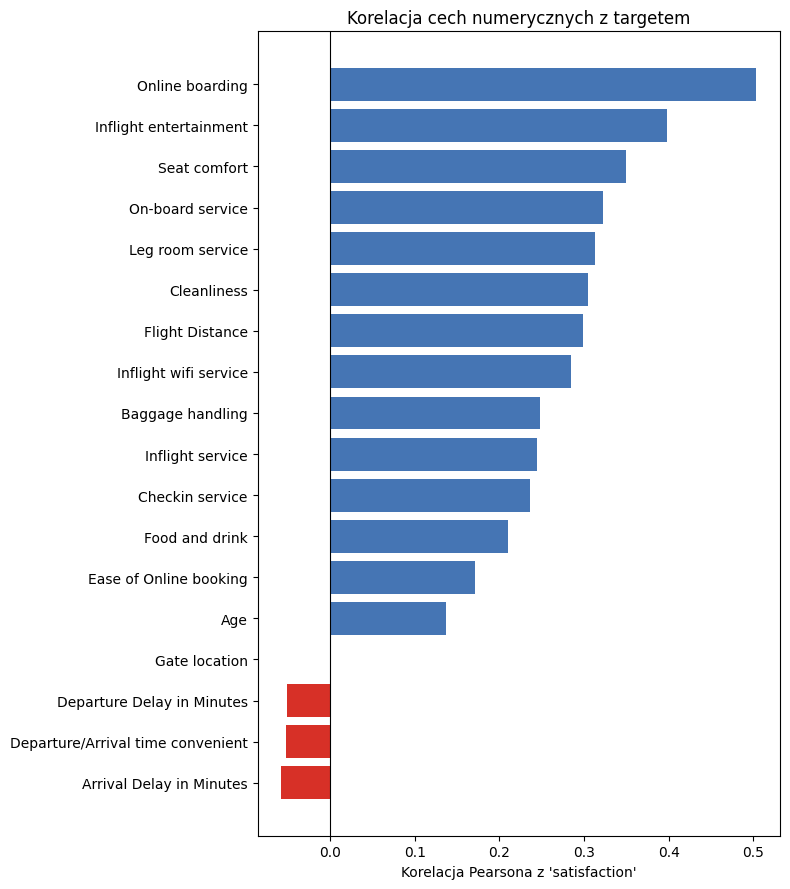

In [7]:
plot_target_correlation(train_clean)

In [8]:
train_feat = engineer_features(train_clean)
test_feat = engineer_features(test_clean)

print("Nowe kolumny:", [c for c in train_feat.columns if c not in train_clean.columns])
train_feat[["Departure Delay in Minutes", "Arrival Delay in Minutes", "total_delay", "avg_service_score"]].describe()

Nowe kolumny: ['total_delay', 'avg_service_score']


,Departure Delay in Minutes,Arrival Delay in Minutes,total_delay,avg_service_score
count,103904.000000,103594.000000,103594.000000,103904.000000
mean,14.815618,15.178678,29.926617,3.261020
std,38.230901,38.698682,76.149672,0.687624
min,0.000000,0.000000,0.000000,0.846154
25%,0.000000,0.000000,0.000000,2.769231
50%,0.000000,0.000000,2.000000,3.307692
75%,12.000000,13.000000,24.000000,3.769231
max,1592.000000,1584.000000,3176.000000,5.000000


In [9]:
X_train, y_train = split_X_y(train_feat)
X_test, y_test = split_X_y(test_feat)

preprocessor = build_preprocessor(X_train)

print("X_train shape:", X_train.shape)
print("X_test shape: ", X_test.shape)
print("Rozkład klas y_train:\n", y_train.value_counts())

X_train shape: (103904, 24)
X_test shape:  (25976, 24)
Rozkład klas y_train:
 satisfaction
0    58879
1    45025
Name: count, dtype: int64


## Model XGBoost

In [10]:
search = tune_hyperparameters(preprocessor, X_train, y_train)

print("Najlepsze parametry:")
for param, value in search.best_params_.items():
    print(f"  {param}: {value}")
print(f"\nNajlepsze F1 (CV): {search.best_score_:.4f}")

Fitting 5 folds for each of 27 candidates, totalling 135 fits
Najlepsze parametry:
  model__learning_rate: 0.1
  model__max_depth: 7
  model__n_estimators: 300

Najlepsze F1 (CV): 0.9579


In [11]:
cv_scores = cross_validate_model(search.best_estimator_, X_train, y_train)

print("Walidacja krzyżowa najlepszego modelu (5-fold):")
print(cv_scores.to_string(index=False))
print("\nŚrednie:")
print(cv_scores.mean().map("{:.4f}".format).to_string())
print("\nOdchylenia standardowe:")
print(cv_scores.std().map("{:.4f}".format).to_string())

Walidacja krzyżowa najlepszego modelu (5-fold):
 accuracy       f1  roc_auc
 0.962899 0.956566 0.995235
 0.962803 0.956414 0.994918
 0.965497 0.959626 0.995523
 0.964294 0.958230 0.995558
 0.961598 0.955027 0.994673

Średnie:
accuracy    0.9634
f1          0.9572
roc_auc     0.9952

Odchylenia standardowe:
accuracy    0.0015
f1          0.0018
roc_auc     0.0004


In [12]:
best_model = search.best_estimator_
metrics = evaluate(best_model, X_test, y_test)

accuracy    0.9644
f1          0.9589
roc_auc     0.9955

              precision    recall  f1-score   support

dissatisfied       0.96      0.98      0.97     14573
   satisfied       0.97      0.95      0.96     11403

    accuracy                           0.96     25976
   macro avg       0.97      0.96      0.96     25976
weighted avg       0.96      0.96      0.96     25976

